Train on 60000 samples, validate on 10000 samples
Epoch 1/20
60000/60000 [==============================] - 8s 127us/sample - loss: 0.4904 - acc: 0.8247 - val_loss: 0.4160 - val_acc: 0.8497
Epoch 2/20
60000/60000 [==============================] - 5s 86us/sample - loss: 0.3663 - acc: 0.8664 - val_loss: 0.3934 - val_acc: 0.8518
Epoch 3/20
60000/60000 [==============================] - 5s 90us/sample - loss: 0.3319 - acc: 0.8785 - val_loss: 0.3655 - val_acc: 0.8665
Epoch 4/20
60000/60000 [==============================] - 5s 80us/sample - loss: 0.3088 - acc: 0.8862 - val_loss: 0.3513 - val_acc: 0.8745
Epoch 5/20
60000/60000 [==============================] - 5s 86us/sample - loss: 0.2936 - acc: 0.8903 - val_loss: 0.3599 - val_acc: 0.8671
Epoch 6/20
60000/60000 [==============================] - 5s 80us/sample - loss: 0.2805 - acc: 0.8955 - val_loss: 0.3528 - val_acc: 0.8762
Epoch 7/20
60000/60000 [==============================] - 5s 80us/sample - loss: 0.2680 - acc: 0.8999 - val_loss: 0

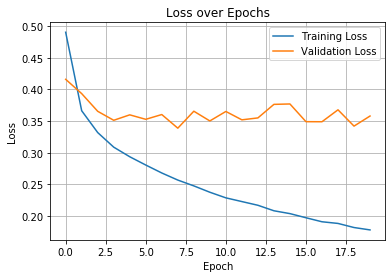

In [13]:
# Importing TensorFlow library (used for building and training neural networks)
import tensorflow as tf

# Importing necessary classes for building a Sequential model and layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Importing the Fashion MNIST dataset (images of clothing items)
from tensorflow.keras.datasets import fashion_mnist

# Importing utility to convert labels into one-hot encoded format
from tensorflow.keras.utils import to_categorical

# Importing categorical cross-entropy loss function for multi-class classification
from tensorflow.keras.losses import CategoricalCrossentropy

# Importing matplotlib for plotting graphs
import matplotlib.pyplot as plt

# Loading Fashion MNIST dataset and splitting into training and testing sets
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()

# Normalizing image pixel values to range [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# Reshaping images from 28x28 to 784 (flattening each image)
X_train = X_train.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

# Converting integer labels to one-hot encoded vectors (10 classes)
Y_train = to_categorical(Y_train, 10)
Y_test = to_categorical(Y_test, 10)

# Defining a Sequential neural network model with 3 layers:
# - First hidden layer with 128 neurons and ReLU activation
# - Second hidden layer with 64 neurons and ReLU activation
# - Output layer with 10 neurons (one per class) and softmax activation
model = Sequential([
    Dense(units=128, activation='relu', input_shape=(784,)),
    Dense(units=64, activation='relu'),
    Dense(units=10, activation='softmax')
])

# Compiling the model:
# - Optimizer: Adam (adaptive learning rate)
# - Loss function: Categorical Crossentropy (for multi-class classification)
# - Metrics: Accuracy (to evaluate performance)
model.compile(
    optimizer='adam',
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

# Training the model for 20 epochs with batch size of 32
# Also evaluating on validation (test) data during training
history = model.fit(X_train, Y_train, epochs=20, batch_size=32, validation_data=(X_test, Y_test))

# Evaluating the trained model on test data to get final loss and accuracy
loss, accuracy = model.evaluate(X_test, Y_test)

# Printing final accuracy as a percentage
print(f" Accuracy : {accuracy * 100:.2f}%")

# Plotting the training and validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()



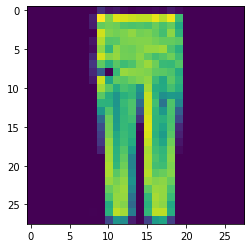

Actual label: Trouser


In [14]:
# Importing matplotlib to display images
import matplotlib.pyplot as plt

# Importing numpy to perform numerical operations (like argmax)
import numpy as np

# Defining the class names corresponding to the labels in Fashion MNIST
# These are human-readable names for each category (0 to 9)
class_name = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'coat', 'sandal', 'Shirt', 'sneaker', 'bag', 'ankle boot']

# Selecting the index of the image you want to test (e.g., image number 200)
index = 200

# Making a prediction for that specific image
# We reshape it to (1, 784) because model expects input shape as a batch
prediction = model.predict(X_test[index].reshape(1, 28 * 28))

# Displaying the selected image in 2D (28x28)
plt.imshow(X_test[index].reshape(28, 28))
plt.show()

# Printing the actual label name for the selected image
# np.argmax(Y_test[index]) gives the class index; we use it to look up the class name
print("Actual label:" , class_name[np.argmax(Y_test[index])])
